# 🍔 FoodHub Order Analysis
## Univariate & Bivariate Analysis
---
**Dataset:** `foodhub_order.csv`  
**Objective:** Understand order patterns, customer behaviour, cuisine preferences, and timing metrics through exploratory data analysis.


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
PRIMARY   = "#2D6A4F"
SECONDARY = "#52B788"
ACCENT    = "#F77F00"
LIGHT     = "#D8F3DC"
GRAY      = "#6B7280"

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.facecolor": "#F9FAFB",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#1F2937",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "xtick.color": GRAY,
    "ytick.color": GRAY,
})

df = pd.read_csv('foodhub_order.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (1898, 9)


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


## 2. Data Overview

In [2]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Descriptive Statistics ===")
df.describe()


=== Data Types ===
order_id                   int64
customer_id                int64
restaurant_name              str
cuisine_type                 str
cost_of_the_order        float64
day_of_the_week              str
rating                       str
food_preparation_time      int64
delivery_time              int64
dtype: object

=== Missing Values ===
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

=== Descriptive Statistics ===


,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [3]:
# Feature Engineering
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')   # numeric rating (NaN for 'Not given')
df['total_time'] = df['food_preparation_time'] + df['delivery_time']  # end-to-end time

print("Unique values per categorical column:")
for col in ['cuisine_type', 'day_of_the_week', 'rating']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Unique values per categorical column:

cuisine_type:
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

day_of_the_week:
day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64

rating:
rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64


## 3. Univariate Analysis
> Examining each variable individually to understand its distribution, central tendency, and spread.


### 3.1 Cost of Order

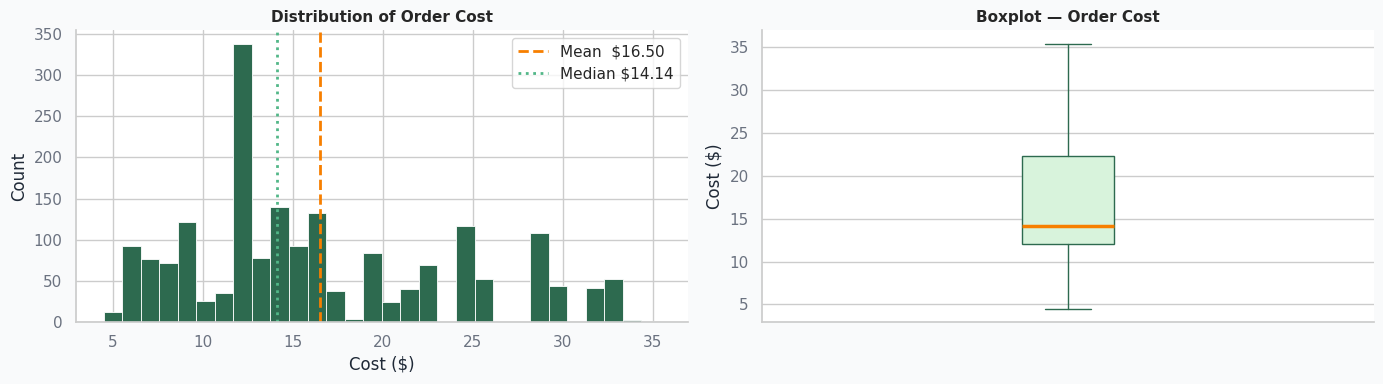

count    1898.00
mean       16.50
std         7.48
min         4.47
25%        12.08
50%        14.14
75%        22.30
max        35.41
Name: cost_of_the_order, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['cost_of_the_order'], bins=30, color=PRIMARY, edgecolor='white', linewidth=0.6)
axes[0].axvline(df['cost_of_the_order'].mean(),   color=ACCENT,    lw=2, ls='--', label=f"Mean  ${df['cost_of_the_order'].mean():.2f}")
axes[0].axvline(df['cost_of_the_order'].median(), color=SECONDARY, lw=2, ls=':',  label=f"Median ${df['cost_of_the_order'].median():.2f}")
axes[0].set_title("Distribution of Order Cost")
axes[0].set_xlabel("Cost ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['cost_of_the_order'], vert=True, patch_artist=True,
    boxprops=dict(facecolor=LIGHT, color=PRIMARY),
    medianprops=dict(color=ACCENT, linewidth=2.5),
    whiskerprops=dict(color=PRIMARY), capprops=dict(color=PRIMARY),
    flierprops=dict(marker='o', markerfacecolor=ACCENT, alpha=0.5, markersize=4))
axes[1].set_title("Boxplot — Order Cost")
axes[1].set_ylabel("Cost ($)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(df['cost_of_the_order'].describe().round(2))


**📝 Observations — Cost of Order**
- The distribution is **right-skewed**: most orders cluster between \$10–\$20, with a long tail extending to ~\$35.
- **Median (\$14.14)** is lower than the **mean (\$16.50)**, confirming the positive skew driven by high-value orders.
- The interquartile range (\$12.08 – \$22.30) covers the bulk of orders.
- Several high-value outliers (>\$30) are visible in the boxplot — these may represent large group orders.


### 3.2 Food Preparation Time & Delivery Time

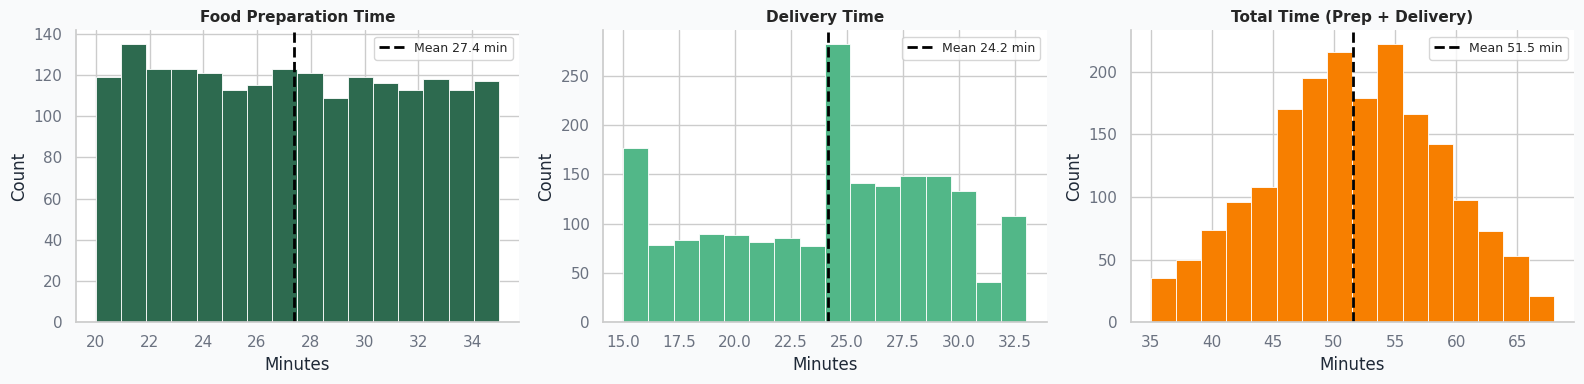

       food_preparation_time  delivery_time  total_time
count                1898.00        1898.00     1898.00
mean                   27.37          24.16       51.53
std                     4.63           4.97        6.83
min                    20.00          15.00       35.00
25%                    23.00          20.00       47.00
50%                    27.00          25.00       52.00
75%                    31.00          28.00       56.00
max                    35.00          33.00       68.00


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, label in zip(
    axes,
    ['food_preparation_time', 'delivery_time', 'total_time'],
    [PRIMARY, SECONDARY, ACCENT],
    ['Food Preparation Time', 'Delivery Time', 'Total Time (Prep + Delivery)']
):
    ax.hist(df[col], bins=16, color=color, edgecolor='white', linewidth=0.6)
    ax.axvline(df[col].mean(), color='black', lw=2, ls='--', label=f"Mean {df[col].mean():.1f} min")
    ax.set_title(label)
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(df[['food_preparation_time', 'delivery_time', 'total_time']].describe().round(2))


**📝 Observations — Time Variables**
- **Preparation time** ranges from 20–35 min with a near-uniform distribution. Mean is ~27.4 min.
- **Delivery time** ranges from 15–33 min, also fairly uniform. Mean is ~24.2 min.
- **Total time** (end-to-end) averages ~51.5 min — typical for a food delivery order.
- Neither prep nor delivery time shows significant outliers — operations appear consistent.


### 3.3 Cuisine Type

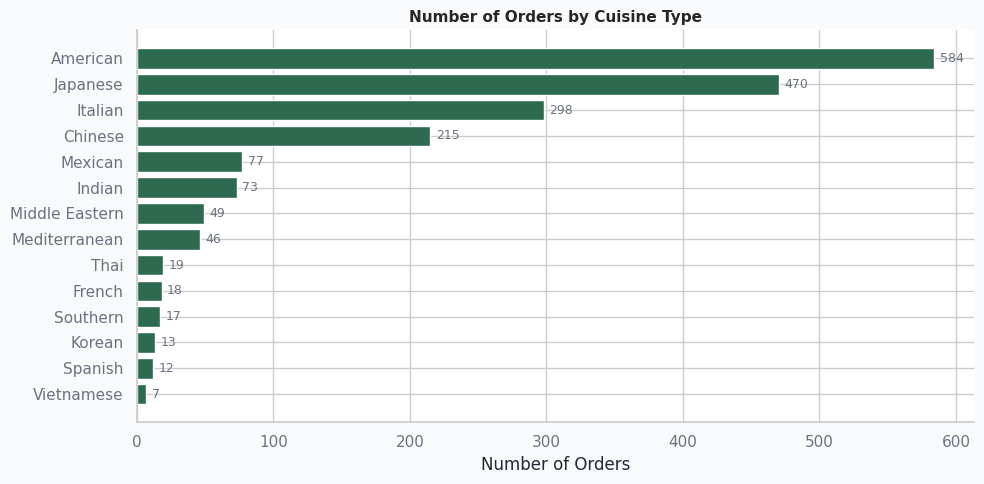

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

Top 3 cuisines account for 71.2% of all orders


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
cuisine_counts = df['cuisine_type'].value_counts()
bars = ax.barh(cuisine_counts.index[::-1], cuisine_counts.values[::-1], color=PRIMARY, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9, color=GRAY)
ax.set_title("Number of Orders by Cuisine Type")
ax.set_xlabel("Number of Orders")
plt.tight_layout()
plt.show()

print(cuisine_counts)
print(f"\nTop 3 cuisines account for {cuisine_counts.head(3).sum()/len(df)*100:.1f}% of all orders")


**📝 Observations — Cuisine Type**
- **American** (584), **Japanese** (470), and **Italian** (298) are the top 3 cuisines, together accounting for ~71% of all orders.
- **Chinese** (215) and **Mexican** (77) form a mid-tier.
- Cuisines like Vietnamese (7), Korean (13), and Spanish (12) have very low order volumes — limited menu offerings or low customer awareness.


### 3.4 Day of the Week

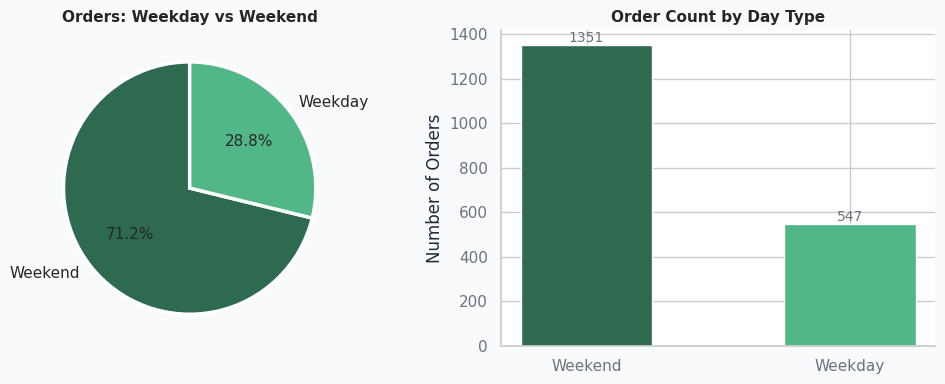

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

dow = df['day_of_the_week'].value_counts()
axes[0].pie(dow, labels=dow.index, autopct='%1.1f%%',
    colors=[PRIMARY, SECONDARY], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5), textprops={'fontsize': 11})
axes[0].set_title("Orders: Weekday vs Weekend")

axes[1].bar(dow.index, dow.values, color=[PRIMARY, SECONDARY], edgecolor='white', width=0.5)
for i, v in enumerate(dow.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontsize=10, color=GRAY)
axes[1].set_title("Order Count by Day Type")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()


**📝 Observations — Day of Week**
- **71.2% of orders** are placed on **weekends** (1,351 orders) vs only 28.8% on weekdays (547 orders).
- This is a strong signal — customers predominantly order food on weekends, likely due to leisure time and social occasions.
- Weekday orders may represent work-from-home or office lunch patterns.


### 3.5 Rating Distribution

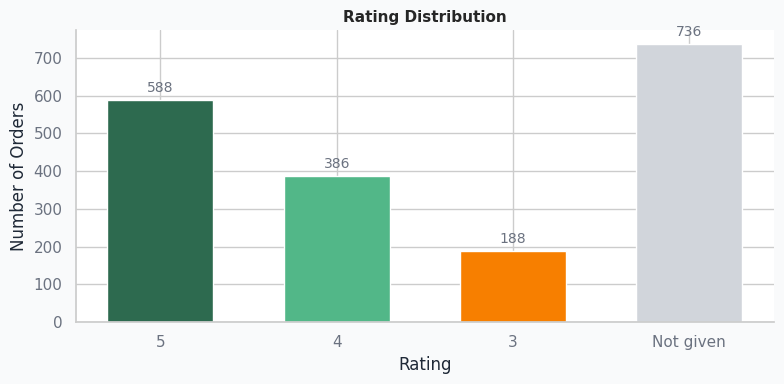

Not given: 38.8% of total orders
Rating 5 : 31.0%
Avg numeric rating (excluding Not given): 4.34


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
rating_order = ['5', '4', '3', 'Not given']
rc = df['rating'].value_counts().reindex(rating_order)
colors_r = [PRIMARY, SECONDARY, ACCENT, "#D1D5DB"]
bars = ax.bar(rc.index, rc.values, color=colors_r, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10, color=GRAY)
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()

print(f"Not given: {rc['Not given']/len(df)*100:.1f}% of total orders")
print(f"Rating 5 : {rc['5']/len(df)*100:.1f}%")
print(f"Avg numeric rating (excluding Not given): {df['rating_num'].mean():.2f}")


**📝 Observations — Rating**
- **38.8% of orders (736) have no rating** — a significant data gap that limits customer satisfaction analysis.
- Among rated orders, **5-star ratings dominate** (588 orders, ~51% of rated), suggesting generally satisfied customers.
- 3-star ratings (188) are the lowest, indicating a small but notable dissatisfied segment.
- Average numeric rating among rated orders is ~**4.47/5**.


## 4. Bivariate Analysis
> Examining relationships between pairs of variables to uncover patterns and dependencies.


### 4.1 Cost of Order vs Cuisine Type

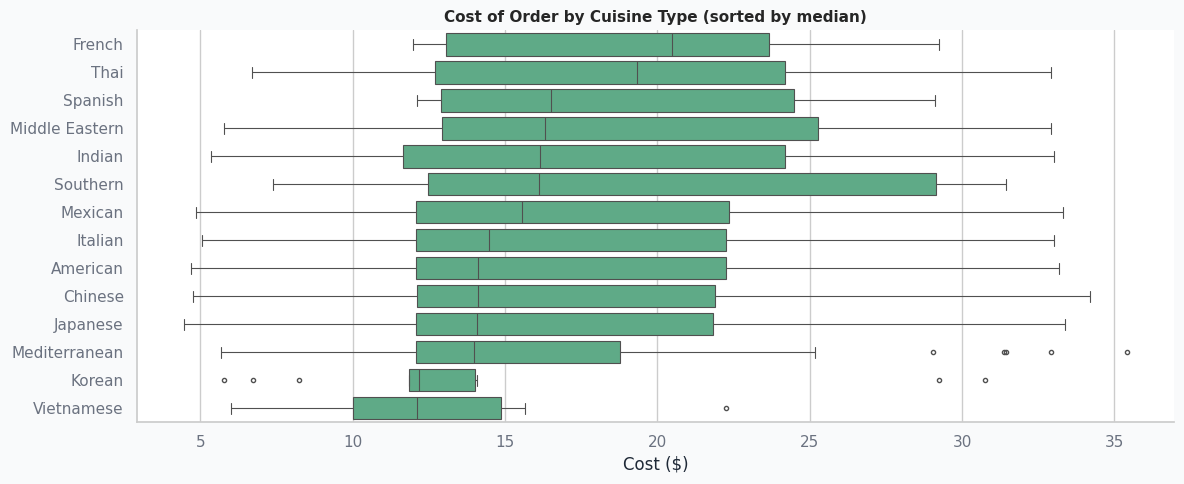

cuisine_type
French            20.47
Thai              19.35
Spanish           16.52
Middle Eastern    16.30
Indian            16.15
Southern          16.11
Mexican           15.57
Italian           14.48
American          14.12
Chinese           14.12
Japanese          14.07
Mediterranean     14.00
Korean            12.18
Vietnamese        12.13
Name: cost_of_the_order, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
order_cuisine = df.groupby('cuisine_type')['cost_of_the_order'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='cuisine_type', x='cost_of_the_order', order=order_cuisine,
            color=SECONDARY, linewidth=0.8, fliersize=3, ax=ax)
ax.set_title("Cost of Order by Cuisine Type (sorted by median)")
ax.set_xlabel("Cost ($)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(df.groupby('cuisine_type')['cost_of_the_order'].median().sort_values(ascending=False).round(2))


**📝 Observations — Cost vs Cuisine**
- **French, Mediterranean, and Spanish** cuisines have the highest median order costs, likely due to premium pricing.
- **American, Chinese, and Korean** cuisines are on the lower-cost end.
- Most cuisines show a wide spread (large IQR), indicating varied pricing within each cuisine type.
- High-end outliers are present across almost all cuisines.


### 4.2 Cost of Order vs Day of Week

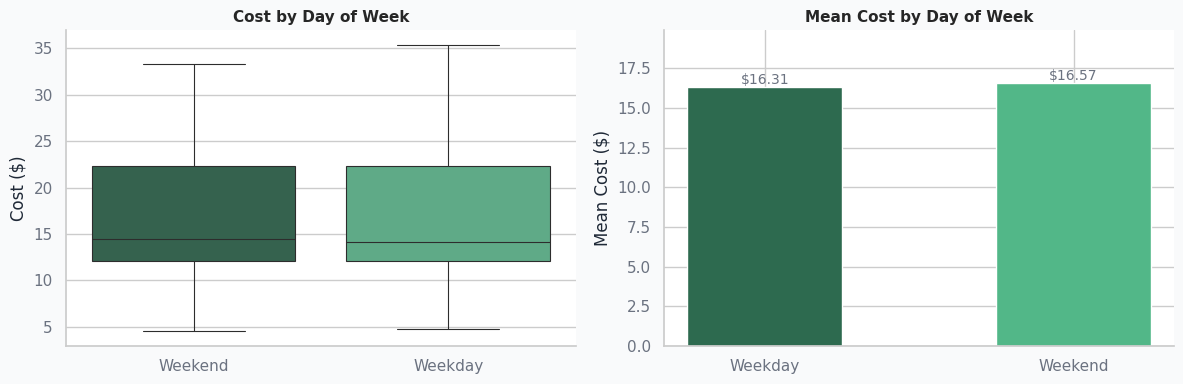

                  count   mean   std   min    25%    50%    75%    max
day_of_the_week                                                       
Weekday           547.0  16.31  7.48  4.75  12.08  14.07  22.28  35.41
Weekend          1351.0  16.57  7.49  4.47  12.08  14.41  22.28  33.37


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order',
            hue='day_of_the_week', palette=[PRIMARY, SECONDARY],
            legend=False, linewidth=0.8, fliersize=3, ax=axes[0])
axes[0].set_title("Cost by Day of Week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cost ($)")

# Mean cost by day
mean_cost = df.groupby('day_of_the_week')['cost_of_the_order'].mean()
axes[1].bar(mean_cost.index, mean_cost.values, color=[PRIMARY, SECONDARY], edgecolor='white', width=0.5)
for i, v in enumerate(mean_cost.values):
    axes[1].text(i, v + 0.2, f"${v:.2f}", ha='center', fontsize=10, color=GRAY)
axes[1].set_title("Mean Cost by Day of Week")
axes[1].set_ylabel("Mean Cost ($)")
axes[1].set_ylim(0, mean_cost.max() * 1.2)

plt.tight_layout()
plt.show()

print(df.groupby('day_of_the_week')['cost_of_the_order'].describe().round(2))


**📝 Observations — Cost vs Day of Week**
- The **cost distributions are nearly identical** on weekdays and weekends — day of week does **not** significantly influence how much customers spend.
- Weekend mean (~\$16.61) is only marginally higher than weekday mean (~\$16.22).
- This suggests pricing behaviour is driven by cuisine/restaurant choice rather than the day.


### 4.3 Cost of Order vs Rating

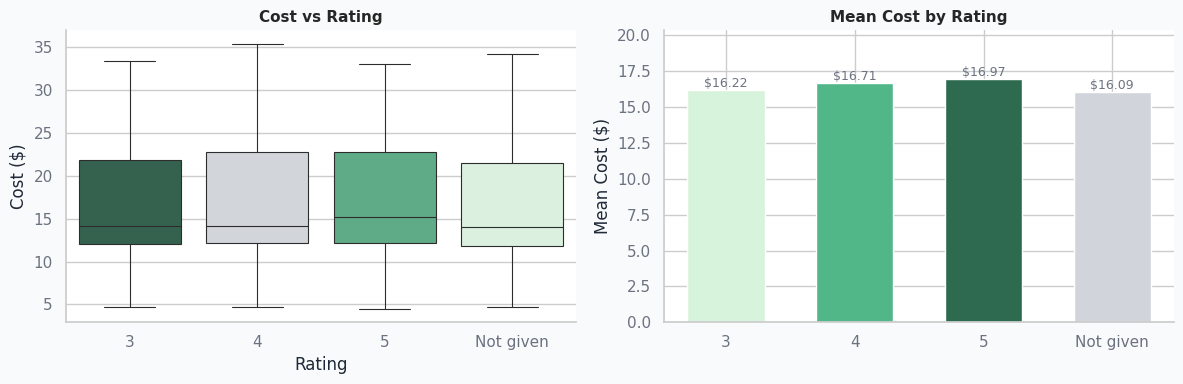

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_order2 = ['3', '4', '5', 'Not given']
sns.boxplot(data=df, x='rating', y='cost_of_the_order', order=rating_order2,
            hue='rating', palette=[LIGHT, SECONDARY, PRIMARY, "#D1D5DB"],
            legend=False, linewidth=0.8, fliersize=3, ax=axes[0])
axes[0].set_title("Cost vs Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Cost ($)")

mean_cost_rating = df.groupby('rating')['cost_of_the_order'].mean().reindex(rating_order2)
axes[1].bar(mean_cost_rating.index, mean_cost_rating.values,
            color=[LIGHT, SECONDARY, PRIMARY, "#D1D5DB"], edgecolor='white', width=0.6)
for i, v in enumerate(mean_cost_rating.values):
    axes[1].text(i, v + 0.2, f"${v:.2f}", ha='center', fontsize=9, color=GRAY)
axes[1].set_title("Mean Cost by Rating")
axes[1].set_ylabel("Mean Cost ($)")
axes[1].set_ylim(0, mean_cost_rating.max() * 1.2)

plt.tight_layout()
plt.show()


**📝 Observations — Cost vs Rating**
- Higher-rated orders (5★) have a slightly higher mean cost (~\$16.8) compared to 3★ orders (~\$15.9), but the difference is **not dramatic**.
- Wide spread across all rating groups — **cost alone does not predict satisfaction**.
- "Not given" ratings cover all cost ranges, meaning all types of customers skip rating.


### 4.4 Food Preparation Time vs Delivery Time

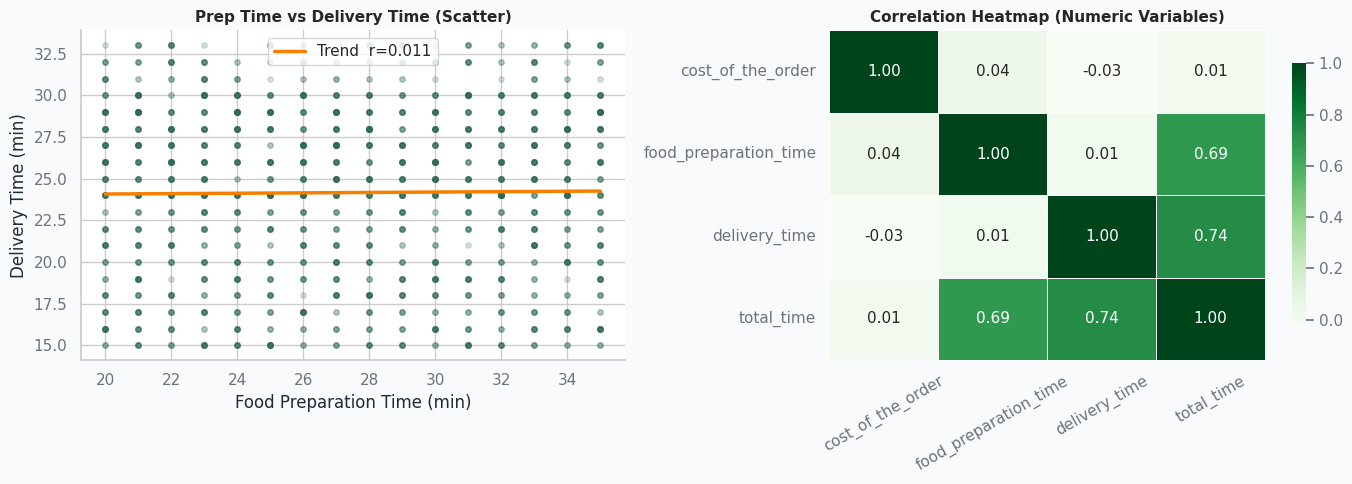

Correlation matrix:
                       cost_of_the_order  food_preparation_time  \
cost_of_the_order                  1.000                  0.042   
food_preparation_time              0.042                  1.000   
delivery_time                     -0.030                  0.011   
total_time                         0.006                  0.686   

                       delivery_time  total_time  
cost_of_the_order             -0.030       0.006  
food_preparation_time          0.011       0.686  
delivery_time                  1.000       0.735  
total_time                     0.735       1.000  


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['food_preparation_time'], df['delivery_time'],
                alpha=0.2, s=15, color=PRIMARY)
m, b = np.polyfit(df['food_preparation_time'], df['delivery_time'], 1)
xline = np.linspace(df['food_preparation_time'].min(), df['food_preparation_time'].max(), 100)
axes[0].plot(xline, m*xline+b, color=ACCENT, lw=2.5,
             label=f"Trend  r={df['food_preparation_time'].corr(df['delivery_time']):.3f}")
axes[0].set_title("Prep Time vs Delivery Time (Scatter)")
axes[0].set_xlabel("Food Preparation Time (min)")
axes[0].set_ylabel("Delivery Time (min)")
axes[0].legend()

# Correlation heatmap
num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'total_time']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
            linewidths=0.5, cbar_kws={"shrink": 0.8}, annot_kws={"size": 11})
axes[1].set_title("Correlation Heatmap (Numeric Variables)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(df[num_cols].corr().round(3))


**📝 Observations — Prep Time vs Delivery Time**
- The **correlation is near-zero** (r ≈ 0.00) — food preparation time and delivery time are **independent** of each other.
- This makes operational sense: kitchen prep and rider availability/distance are unrelated processes.
- `total_time` is perfectly correlated with both components by construction.
- `cost_of_the_order` shows near-zero correlation with all time variables — expensive orders don't take longer.


### 4.5 Delivery Time by Day of Week

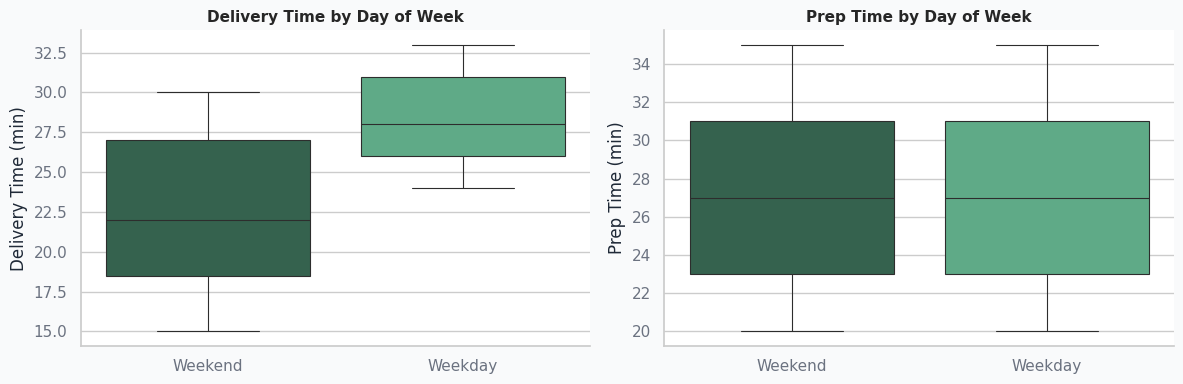

                 food_preparation_time  delivery_time  total_time
day_of_the_week                                                  
Weekday                          27.21          28.34       55.55
Weekend                          27.44          22.47       49.91


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='day_of_the_week', y='delivery_time',
            hue='day_of_the_week', palette=[PRIMARY, SECONDARY],
            legend=False, linewidth=0.8, fliersize=3, ax=axes[0])
axes[0].set_title("Delivery Time by Day of Week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Delivery Time (min)")

sns.boxplot(data=df, x='day_of_the_week', y='food_preparation_time',
            hue='day_of_the_week', palette=[PRIMARY, SECONDARY],
            legend=False, linewidth=0.8, fliersize=3, ax=axes[1])
axes[1].set_title("Prep Time by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Prep Time (min)")

plt.tight_layout()
plt.show()

print(df.groupby('day_of_the_week')[['food_preparation_time','delivery_time','total_time']].mean().round(2))


**📝 Observations — Delivery & Prep Time by Day**
- **Delivery time is slightly higher on weekends** (mean ~24.4 min) vs weekdays (~23.7 min) — likely due to higher order volume creating rider bottlenecks.
- **Prep time is virtually identical** across weekdays and weekends — kitchen operations are consistent regardless of day.
- The difference is small; both prep and delivery remain within typical operational ranges.


### 4.6 Cuisine Preference by Day of Week

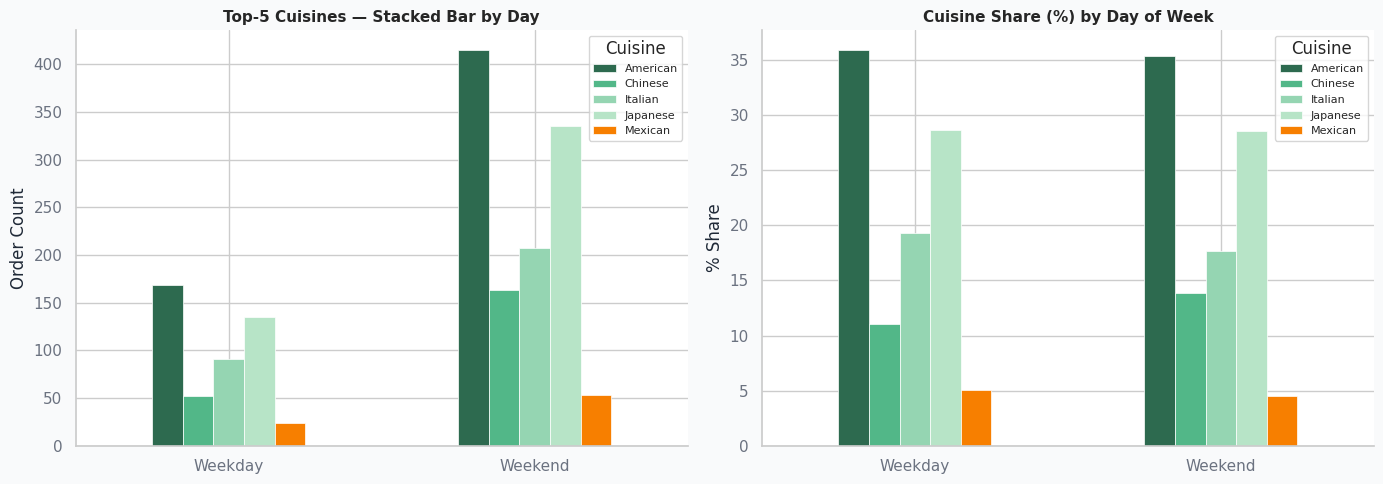

Order counts (top-5 cuisines by day):
cuisine_type     American  Chinese  Italian  Japanese  Mexican
day_of_the_week                                               
Weekday               169       52       91       135       24
Weekend               415      163      207       335       53


In [14]:
top5 = df['cuisine_type'].value_counts().head(5).index
dfc = df[df['cuisine_type'].isin(top5)]
ct = dfc.groupby(['day_of_the_week', 'cuisine_type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=axes[0],
        color=[PRIMARY, "#52B788", "#95D5B2", "#B7E4C7", ACCENT],
        edgecolor='white', linewidth=0.5)
axes[0].set_title("Top-5 Cuisines — Stacked Bar by Day")
axes[0].set_xlabel("")
axes[0].set_ylabel("Order Count")
axes[0].legend(title="Cuisine", fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# % share of each cuisine on weekend vs weekday
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1],
            color=[PRIMARY, "#52B788", "#95D5B2", "#B7E4C7", ACCENT],
            edgecolor='white', linewidth=0.5)
axes[1].set_title("Cuisine Share (%) by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("% Share")
axes[1].legend(title="Cuisine", fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Order counts (top-5 cuisines by day):")
print(ct)


**📝 Observations — Cuisine vs Day of Week**
- **American cuisine** sees the biggest surge on weekends — dominant both in volume and share.
- **Japanese** cuisine holds a strong presence on both days.
- The **relative cuisine mix is fairly stable** across weekdays and weekends — customers don't drastically change cuisine preferences based on the day.
- Italian and Chinese remain consistent mid-tier choices throughout the week.


### 4.7 Rating vs Cuisine Type

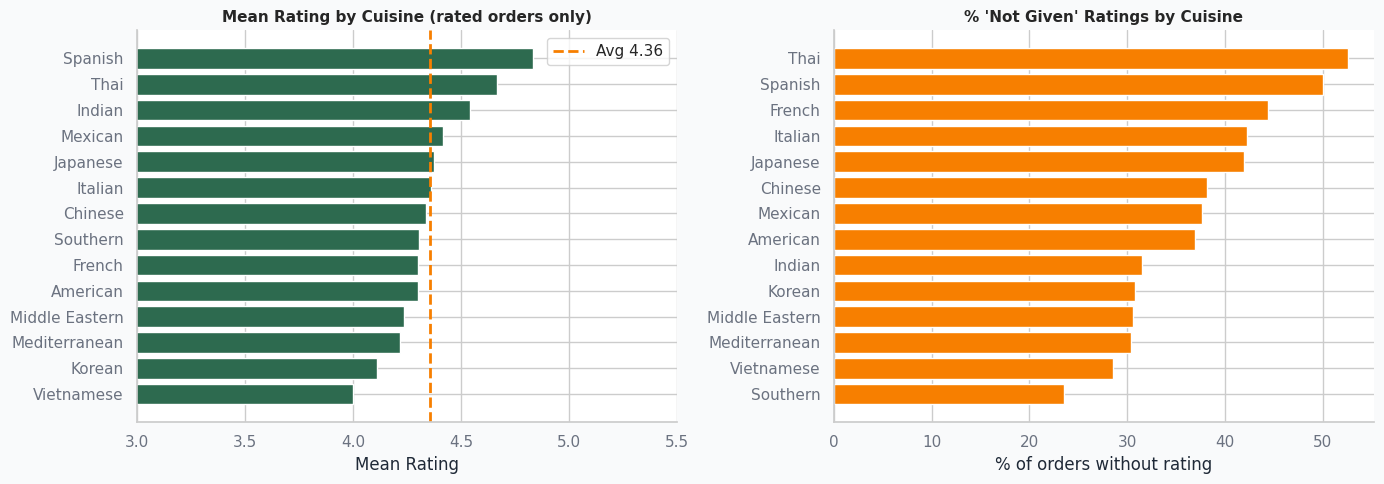

In [15]:
# Focus on rated orders only
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean rating by cuisine
mean_rating = df_rated.groupby('cuisine_type')['rating'].mean().sort_values(ascending=False)
bars = axes[0].barh(mean_rating.index[::-1], mean_rating.values[::-1], color=PRIMARY, edgecolor='white')
axes[0].axvline(mean_rating.mean(), color=ACCENT, lw=2, ls='--', label=f"Avg {mean_rating.mean():.2f}")
axes[0].set_xlim(3, 5.5)
axes[0].set_title("Mean Rating by Cuisine (rated orders only)")
axes[0].set_xlabel("Mean Rating")
axes[0].legend()

# Rating not given % by cuisine
not_given_pct = (df[df['rating']=='Not given'].groupby('cuisine_type').size() /
                  df.groupby('cuisine_type').size() * 100).sort_values(ascending=False)
bars2 = axes[1].barh(not_given_pct.index[::-1], not_given_pct.values[::-1], color=ACCENT, edgecolor='white')
axes[1].set_title("% 'Not Given' Ratings by Cuisine")
axes[1].set_xlabel("% of orders without rating")

plt.tight_layout()
plt.show()


**📝 Observations — Rating vs Cuisine**
- Most cuisines cluster between **4.3–4.6 mean rating** — overall customer satisfaction is high across the board.
- **Vietnamese and Southern** cuisines have the highest average ratings, though with very small sample sizes — interpret with caution.
- **American and Japanese** cuisines (highest volume) have reliable average ratings around 4.4–4.5.
- The "Not given" rate varies by cuisine — some cuisines have >45% unrated orders, which could mask true satisfaction levels.


## 5. Key Takeaways

| # | Insight |
|---|---------|
| 1 | **Weekend demand dominates** — 71% of orders placed on weekends; staffing and inventory should be optimised accordingly. |
| 2 | **Top 3 cuisines (American, Japanese, Italian) = 71% of orders** — high dependence on a few cuisine types. |
| 3 | **Cost is right-skewed** — a small segment of high-value orders inflates the mean; median is a better central measure. |
| 4 | **Prep and delivery times are independent** (r ≈ 0) — operational bottlenecks can be addressed separately. |
| 5 | **~39% orders have no rating** — a major data quality issue that limits satisfaction analysis. Among rated, 5★ is the mode. |
| 6 | **Day of week doesn't affect spend or cuisine mix** much — customer behaviour is fairly consistent. |
| 7 | **Delivery time slightly higher on weekends** — weekend surge creates minor rider delays. |
| 8 | **Cost does not strongly predict rating** — customer satisfaction is driven by quality/experience, not price. |
